# 🚗 Car Price Prediction using Machine Learning

### CodeAlpha Data Science Internship – Task 3

👩‍💻 Intern Name: Radhika

💻 Platform: Google Colab

🐍 Programming Language: Machine Learning

# 🎯 Project Objective

The objective of this project is to predict car selling prices using machine learning techniques. Various vehicle attributes such as manufacturing year, fuel type, transmission type, ownership history, and present market price are analyzed to build a predictive regression model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Upload and Load Dataset
The car dataset is uploaded and loaded into a Pandas DataFrame for analysis and machine learning model development.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [ ]:
data = pd.read_csv("car data.csv")

# Step 2: Exploratory Data Analysis (EDA)
Exploratory Data Analysis is performed to understand the structure, quality, and characteristics of the dataset.

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


###  EDA Findings

- Dataset contains 301 records.
- Dataset contains 9 features.
- No missing values are present.
- Dataset is suitable for machine learning analysis.

#  Step 3: Feature Engineering
Machine learning models work with numerical data. Therefore, categorical variables are converted into numerical form and additional useful features are created.

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data['Car_Age'] = 2025 - data['Year']
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


### 🚗 Car Age Feature

A new feature called Car_Age is created from the manufacturing year. Older cars generally have lower market value compared to newer cars.

In [ ]:
data.drop('Year', axis=1, inplace=True)

In [ ]:
data.drop('Car_Name', axis=1, inplace=True)

###  Feature Selection

The columns Year and Car_Name are removed because they are not directly useful for prediction after creating the Car_Age feature.

In [ ]:
data = pd.get_dummies(
    data,
    columns=['Fuel_Type','Selling_type','Transmission'],
    drop_first=True
)

In [ ]:
data.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


#  Data Encoding

Categorical variables are converted into numerical format using One-Hot Encoding so that machine learning algorithms can process them.

In [ ]:
data.columns

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')

#  Step 4: Preparing Data for Machine Learning

The dataset is divided into independent variables (X) and target variable (y). The data is then split into training and testing sets.

In [ ]:
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


## Step 5: Linear Regression Model Training

Linear Regression is used to predict the selling price of cars based on various independent variables such as present price, car age, fuel type, transmission type, and kilometers driven.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


## Model Prediction

The trained model is used to predict car selling prices on the test dataset.

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 2.95433731  8.17716341  6.45612271 -1.42337164  9.08864657  7.41793553
  1.33513921  0.84032259  1.36320242  7.49067757]


## Model Evaluation
The performance of the Linear Regression model is evaluated using MAE, RMSE and R² Score.

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 1.2163740193330348
MSE = 3.4813498305118165
RMSE = 1.865837568094237
R2 Score = 0.8488707839193155


## Actual vs Predicted Price Comparison
A scatter plot is created to compare actual selling prices with predicted selling prices.

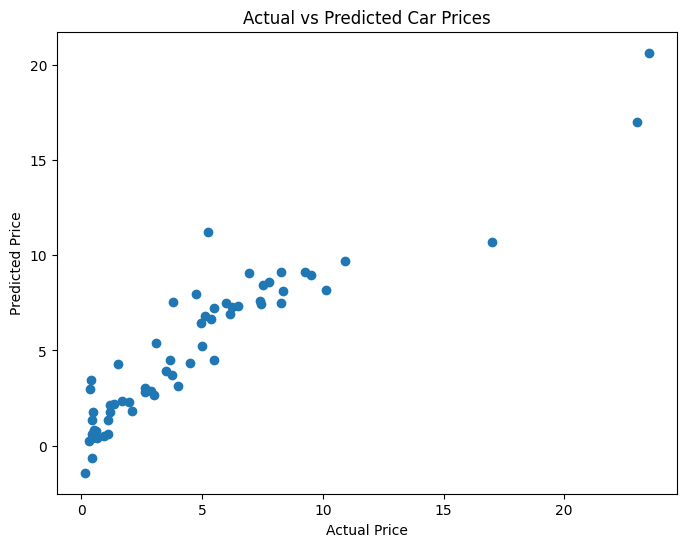

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

## Feature Importance Analysis
The coefficients of the Linear Regression model indicate how each feature influences the selling price prediction.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
4,Fuel_Type_Diesel,2.534904
5,Fuel_Type_Petrol,0.739155
0,Present_Price,0.429070
1,Driven_kms,-0.000006
3,Car_Age,-0.352925
2,Owner,-0.905018
6,Selling_type_Individual,-1.191642
7,Transmission_Manual,-1.640074


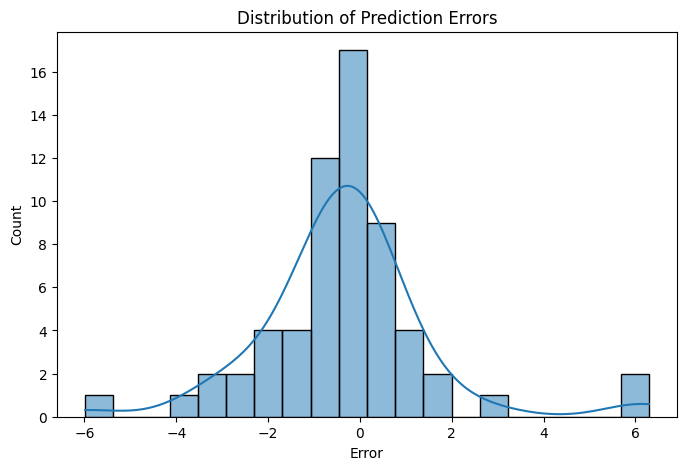

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(y_test - y_pred, bins=20, kde=True)

plt.title("Distribution of Prediction Errors")

plt.xlabel("Error")

plt.show()

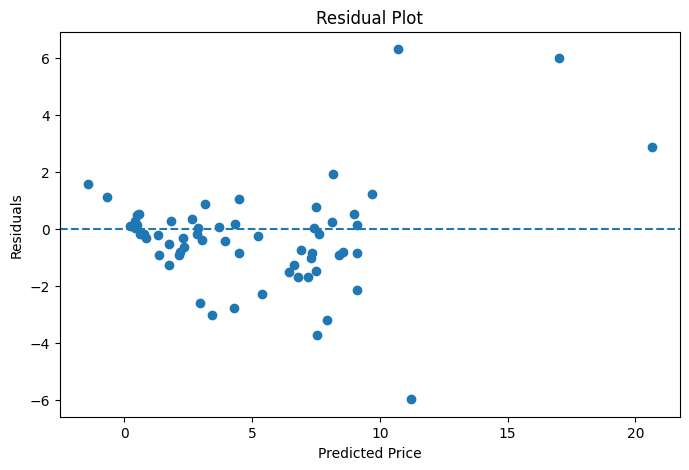

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# Conclusion
The Linear Regression model was successfully trained to predict car selling prices.

The model achieved an R² Score of 0.8488, indicating that approximately 84.88% of the variance in selling prices is explained by the model.

The evaluation metrics show good predictive performance:

• MAE = 1.21

• RMSE = 1.86

• R² Score = 0.8488

Feature importance analysis revealed that Fuel Type, Present Price and Transmission Type significantly influence car selling prices.

This project demonstrates the application of machine learning for car price prediction using Linear Regression.